In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score

## PREPROCESAMIENTO DE DATOS

** Importación de datasets **

In [ ]:
# Importación de datos de las operaciones de los operadores

operator = pd.read_csv('/datasets/telecom_dataset_us.csv',
                          dtype={'direction':'category', 'internal':'boolean'},
                          parse_dates = ['date'])
display(operator.info())
display(operator.describe(include='all', datetime_is_numeric=True))
display(operator.head())
print('Cuenta con',operator.duplicated().sum(),'datos duplicados')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  int64                                
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  category                             
 3   internal             53785 non-null  boolean                              
 4   operator_id          45730 non-null  float64                              
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
dtypes: bool

None

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
count,53902.000000,53902,53902,53785,45730.000000,53902,53902.000000,53902.000000,53902.000000
unique,NaN,NaN,2,2,NaN,2,NaN,NaN,NaN
top,NaN,NaN,out,False,NaN,False,NaN,NaN,NaN
freq,NaN,NaN,31917,47621,NaN,30334,NaN,NaN,NaN
mean,167295.344477,2019-10-23 01:00:32.191755520+03:00,NaN,NaN,916535.993002,NaN,16.451245,866.684427,1157.133297
min,166377.000000,2019-08-02 00:00:00+03:00,NaN,NaN,879896.000000,NaN,1.000000,0.000000,0.000000
25%,166782.000000,2019-10-04 00:00:00+03:00,NaN,NaN,900788.000000,NaN,1.000000,0.000000,47.000000
50%,167162.000000,2019-10-28 00:00:00+03:00,NaN,NaN,913938.000000,NaN,4.000000,38.000000,210.000000
75%,167819.000000,2019-11-14 00:00:00+03:00,NaN,NaN,937708.000000,NaN,12.000000,572.000000,902.000000
max,168606.000000,2019-11-28 00:00:00+03:00,NaN,NaN,973286.000000,NaN,4817.000000,144395.000000,166155.000000


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


Cuenta con 4900 datos duplicados


In [ ]:
# Importación de datos de los clientes

clients = pd.read_csv('/datasets/telecom_clients_us.csv',
                        dtype={'tariff_plan':'category',},
                        parse_dates =['date_start'])
display(clients.info())
display(clients.describe(include='all', datetime_is_numeric=True))
display(clients.head())
print('Cuenta con', clients.duplicated().sum(),'datos duplicados')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    category      
 2   date_start   732 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 12.4 KB


None

,user_id,tariff_plan,date_start
count,732.000000,732,732
unique,NaN,3,NaN
top,NaN,C,NaN
freq,NaN,395,NaN
mean,167431.927596,NaN,2019-09-14 16:39:20.655737600
min,166373.000000,NaN,2019-08-01 00:00:00
25%,166900.750000,NaN,2019-08-23 00:00:00
50%,167432.000000,NaN,2019-09-16 00:00:00
75%,167973.000000,NaN,2019-10-08 00:00:00
max,168606.000000,NaN,2019-10-31 00:00:00


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


Cuenta con 0 datos duplicados


- La columna 'internal' cuenta con 117 valores nulos
- La columna 'operator_id' con 8.172 valores nulos, siendo un 17% de los valores.
- La columna 'operator_id' (float64) por estos valores. Además cuenta con 4900 datos duplicados, siendo un 10%.

** Formateo de datasets **

In [ ]:
# Formatear las fechas con el día

operator['date'] = pd.to_datetime(operator['date'])
operator['date_format'] = operator['date'].dt.date
operator['month_format'] = operator['date'].dt.month
operator['day_format'] = operator['date'].dt.strftime('%m-%d')

# Calcular la diferencia del tiempo de espera por llamada

operator['call_waiting_time'] = operator['total_call_duration'] - operator['call_duration']
display(operator.head())

# Formatear las fechas con el día

clients['date_start'] = clients['date_start'].dt.date
clients['date_start'] = pd.to_datetime(clients['date_start'])
clients['month_start'] = clients['date_start'].dt.month
clients['day_start'] = clients['date_start'].dt.strftime('%m-%d')

display(clients.head())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_format,month_format,day_format,call_waiting_time
0,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,2019-08-05,8,08-05,5
1,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,2019-08-05,8,08-05,1
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,2019-08-05,8,08-05,8
3,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,2019-08-05,8,08-05,25
4,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,2019-08-05,8,08-05,26


,user_id,tariff_plan,date_start,month_start,day_start
0,166713,A,2019-08-15,8,08-15
1,166901,A,2019-08-23,8,08-23
2,168527,A,2019-10-29,10,10-29
3,167097,A,2019-09-01,9,09-01
4,168193,A,2019-10-16,10,10-16


** Valores nulos y valores duplicados en los datasets **

In [ ]:
# Valores nulos en operator

display(operator.isna().sum())
operator=operator[~operator['operator_id'].isna()]
display(operator.isna().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
date_format               0
month_format              0
day_format                0
call_waiting_time         0
dtype: int64

user_id                 0
date                    0
direction               0
internal               60
operator_id             0
is_missed_call          0
calls_count             0
call_duration           0
total_call_duration     0
date_format             0
month_format            0
day_format              0
call_waiting_time       0
dtype: int64

In [ ]:
# Valores duplicados

print('El número total de registros de las operaciones de los operadores son {} y cuenta con {} ({}%) duplicados'.format(len(operator), operator.duplicated().sum(),((operator.duplicated().sum()/len(operator))*100).round(2)))
print('El número total de registros de los clientes son {} y cuenta con {} ({}%) duplicados'.format(len(clients), clients.duplicated().sum(),((clients.duplicated().sum()/len(clients))*100).round(2)))

El número total de registros de las operaciones de los operadores son 45730 y cuenta con 4184 (9.15%) duplicados
El número total de registros de los clientes son 732 y cuenta con 0 (0.0%) duplicados


In [ ]:
# Eliminar valores duplicados

operator.drop_duplicates(inplace=True, ignore_index=True)

** Revisión de correlación de las caracteristicas del servicio recibido por los clientes. **

In [ ]:
# Unir tablas
merge = clients[['user_id','tariff_plan']]
merge = merge.merge(operator, how='inner', on='user_id')

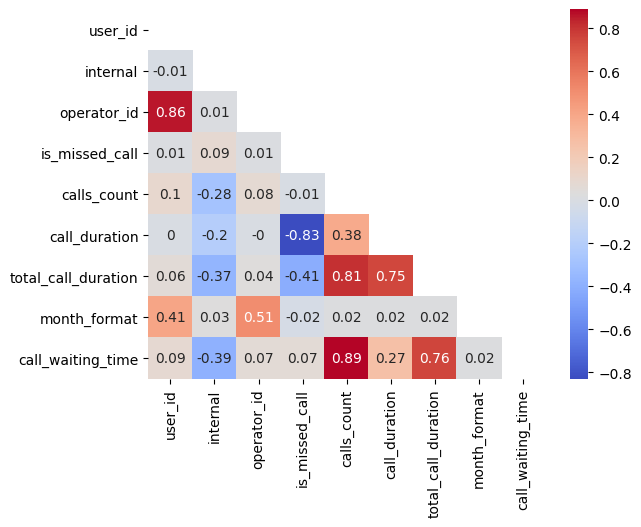

In [ ]:
# Graficar un mapa de calor respecto a la correlación de las variables
corr = merge.corr(method='spearman').round(2)
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

## Análisis de patrones temporales

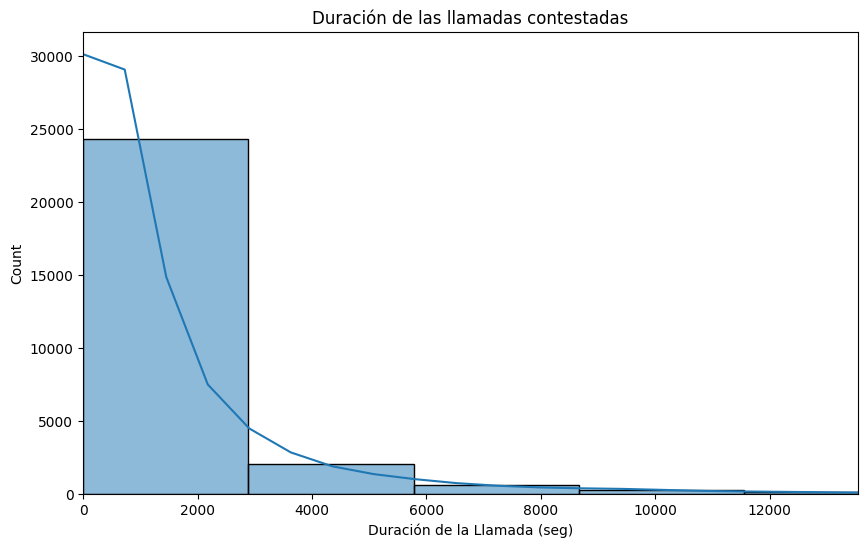

In [ ]:
# Duración de las llamadas contestadas
plt.figure(figsize=(10, 6))
sns.histplot(merge[merge['call_duration'] > 0]['call_duration'], bins=50, kde=True)
plt.title('Duración de las llamadas contestadas')
plt.xlabel('Duración de la Llamada (seg)')
plt.xlim(0, merge[merge['call_duration'] > 0]['call_duration'].quantile(0.99))
plt.show()


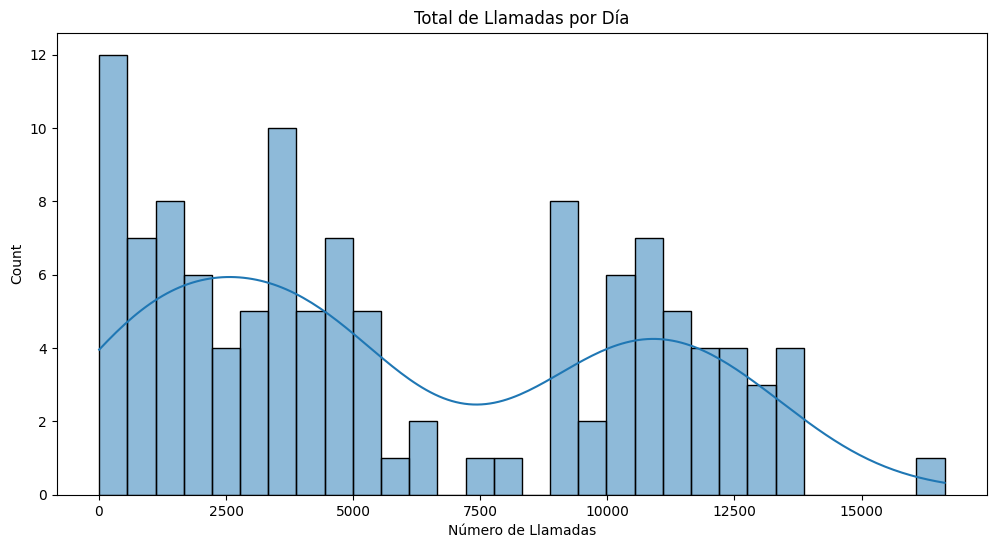

In [ ]:
# Llamadas por día
calls_per_day = merge.groupby(merge['date'].dt.date)['calls_count'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.histplot(calls_per_day['calls_count'], bins=30, kde=True)
plt.title('Total de Llamadas por Día')
plt.xlabel('Número de Llamadas')
plt.show()

In [ ]:
# Variación del desempeño de los operadores

missed_calls = operator.groupby(['month_format','direction','is_missed_call'])['is_missed_call'].count().reset_index(name='count')
missed_calls = missed_calls.pivot(columns=['direction','is_missed_call'],
                                                                  index='month_format',
                                                                  values='count')

missed_calls

direction         in         out      
is_missed_call False True  False True 
month_format                          
8                376    18   526   550
9               1904    99  2569  2365
10              4241   250  5342  4663
11              5527   318  6951  5847

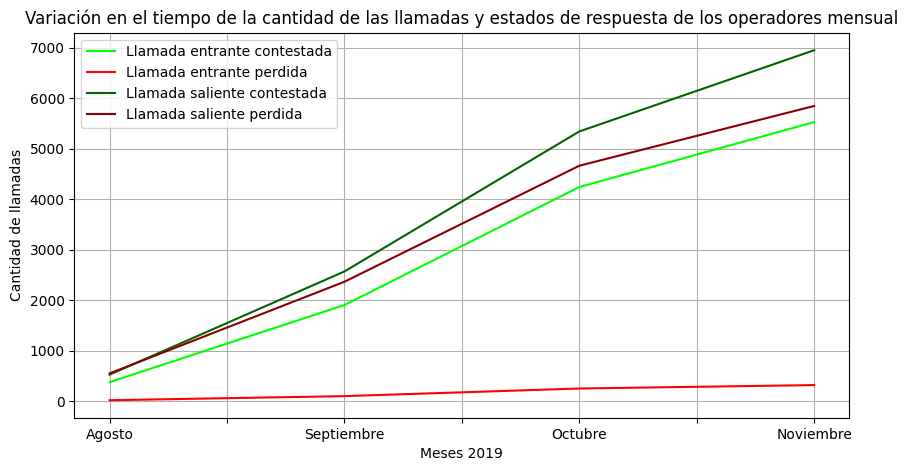

In [ ]:
# Gráfica de variación del desempeño de los operadores
missed_calls.plot(grid=True, figsize=[10, 5],
                     title='Variación en el tiempo de la cantidad de las llamadas y estados de respuesta de los operadores mensual',
                     xlabel='Meses 2019',
                     ylabel='Cantidad de llamadas',
                     color=['#00FF00', '#FF0000', '#006400', '#8B0000'])

plt.xticks([8, 8.5, 9, 9.5, 10, 10.5, 11 ],['Agosto', ' ','Septiembre',' ', 'Octubre', ' ','Noviembre'])
plt.legend(['Llamada entrante contestada', 'Llamada entrante perdida', 'Llamada saliente contestada', 'Llamada saliente perdida'])
plt.show()

In [ ]:
# Llamadas en espera
waiting_time = operator.pivot_table(columns=['direction','is_missed_call'],
                                           index='month_format',
                                           values='call_waiting_time',
                                           aggfunc=['mean','median'])

waiting_time=waiting_time['median']

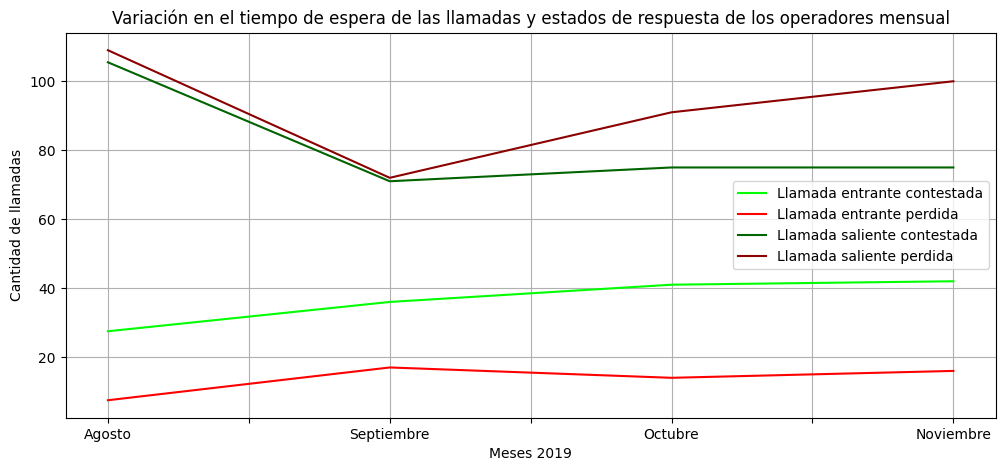

In [ ]:

waiting_time.plot(grid=True,
                      figsize=[12, 5],
                      title='Variación en el tiempo de espera de las llamadas y estados de respuesta de los operadores mensual',
                              xlabel='Meses 2019',
                              ylabel='Cantidad de llamadas',
                              color=['#00FF00', '#FF0000', '#006400', '#8B0000']
                             )

plt.xticks([8, 8.5, 9, 9.5, 10, 10.5, 11 ],['Agosto', ' ','Septiembre',' ', 'Octubre', ' ','Noviembre'])
plt.legend(['Llamada entrante contestada', 'Llamada entrante perdida', 'Llamada saliente contestada', 'Llamada saliente perdida'])
plt.show()

- La ineficiencia está justificada por una saturación operativa. El operador está manejando un volumen de llamadas hasta 7 veces mayor en noviembre que en agosto, lo que dispara los tiempos de espera y las llamadas perdidas de forma matemática, como muestra la correlación de 0.89.
- A partir de septiembre, la línea de llamadas salientes perdidas comienza a subir de forma constante hasta noviembre.
- La gran mayoría de las llamadas se resuelven rápido (antes de los 3,000 segundos), pero existe una "cola larga" de llamadas que duran mucho más.

## ANÁLISIS DE COHORTES

In [ ]:
# Determinar los cohortes de cada usuario
cohortes = clients.merge(operator, how='right', on='user_id')

# Determinar los cohortes de cada usuario
cohortes['cohorte'] = cohortes['month_format'] - cohortes['month_start']
cohortes.head()

,user_id,tariff_plan,date_start,month_start,day_start,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_format,month_format,day_format,call_waiting_time,cohorte
0,166377,B,2019-08-01,8,08-01,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,2019-08-05,8,08-05,5,0
1,166377,B,2019-08-01,8,08-01,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,2019-08-05,8,08-05,1,0
2,166377,B,2019-08-01,8,08-01,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,2019-08-05,8,08-05,8,0
3,166377,B,2019-08-01,8,08-01,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,2019-08-05,8,08-05,25,0
4,166377,B,2019-08-01,8,08-01,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,2019-08-05,8,08-05,26,0


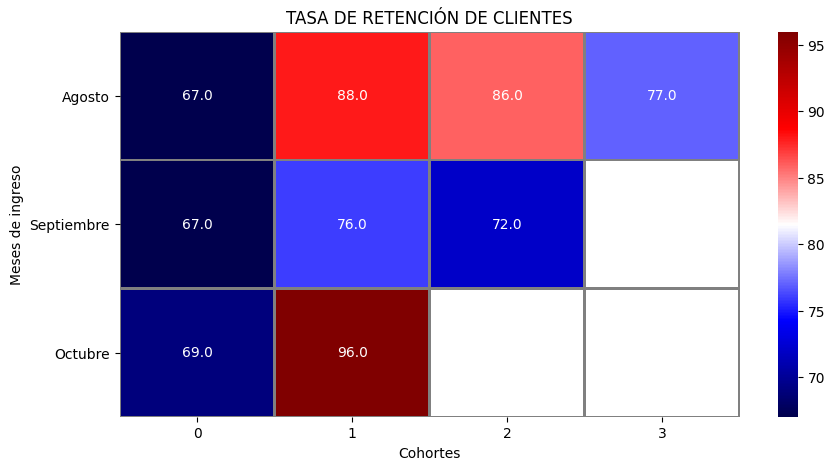

In [ ]:
# Tasa de retención de los clientes
cohorte_user = cohortes.pivot_table(index = 'month_start',
                                        columns ='cohorte',
                                        values = 'user_id',
                                        aggfunc = 'nunique')

# Mapa de calor
plt.figure(figsize=(10, 5))
plt.title('TASA DE RETENCIÓN DE CLIENTES')
heatmap= sns.heatmap(cohorte_user,
                     annot=True,
                     fmt='1',
                     linewidths=1,
                     linecolor='gray',
                     cmap='seismic')
heatmap.set_xlabel('Cohortes')
heatmap.set_ylabel('Meses de ingreso')
index = ['Agosto', 'Septiembre', 'Octubre']
heatmap.set_yticklabels(index, rotation=0)
plt.show()

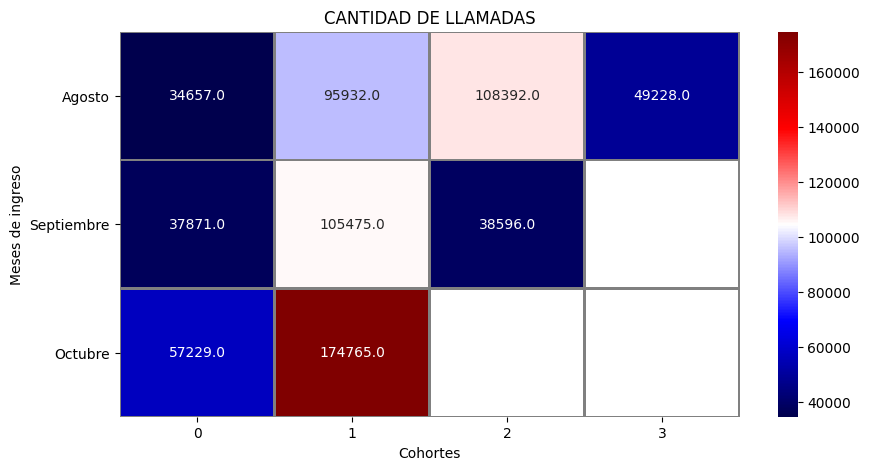

In [ ]:
# Número de llamadas
cohorte_calls = cohortes.pivot_table(index = 'month_start',
                                        columns ='cohorte',
                                        values = 'calls_count',
                                        aggfunc = 'sum')

# Mapa de calor
plt.figure(figsize=(10, 5))
plt.title('CANTIDAD DE LLAMADAS')
heatmap= sns.heatmap(cohorte_calls,
                     annot=True,
                     fmt='1',
                     linewidths=1,
                     linecolor='gray',
                     cmap='seismic')
heatmap.set_xlabel('Cohortes')
heatmap.set_ylabel('Meses de ingreso')
index = ['Agosto', 'Septiembre', 'Octubre']
heatmap.set_yticklabels(index, rotation=0)
plt.show()

Con base al resultado del análisis de los cohortes:
- Eficiencia bajo presión: Los datos sugieren que el equipo de soporte fue más efectivo en retener clientes durante el pico máximo de llamadas de octubre que en los meses anteriores. Esto podría indicar una mejora en los procesos de resolución o una mayor calidad del cliente captado en ese mes.
- Riesgo de abandono temprano: La retención en el "mes 0" (entrada) es la más baja (entre 67% y 69%). El esfuerzo principal de los operadores debe enfocarse en este primer contacto para evitar que el 30% de los clientes se pierda antes de completar su primer mes de vida.
- Justificación de ineficiencia: Al ver que el volumen de llamadas en octubre es casi el doble que en agosto para ciertos periodos, cualquier aumento en el tiempo de espera queda plenamente justificado por la magnitud de la escala operativa.

## Calcular los KPIs significativos

** Respuesta a la primera llamada **

In [ ]:
# Obtener la fecha mínima por usuario
min_date = cohortes.groupby('user_id')['date_format'].min().reset_index()
min_date.columns = ['user_id', 'min_date']

# Unir dataset filtrado y el original
pd_merged = pd.merge(min_date, cohortes, left_on=['user_id', 'min_date'], right_on=['user_id', 'date_format'])

# Filtrar las columnas mostradas
pd_merged = pd_merged[['month_format','user_id', 'calls_count', 'call_duration', 'call_waiting_time', 'total_call_duration']]

# Mostrar la tabla de la media y mediana de la cantidad de llamadas, el tiempo de espera, la duración de la llamada y el total del tiempo mensuales
pd_merged.groupby('month_format').agg({'calls_count':['mean','median'],
                                       'call_waiting_time':['mean','median'],
                                       'call_duration':['mean','median'],
                                       'total_call_duration':['mean','median']})

calls_count        call_waiting_time        call_duration         \
                    mean median              mean median          mean median   
month_format                                                                    
8               8.296089      2        153.245810   26.0    501.944134   20.0   
9               2.968254      1         42.031746   19.0    139.325397   15.5   
10              7.814394      2        133.034091   22.0    366.348485   16.0   
11              3.068182      2         37.420455   17.5     95.136364   13.5   

             total_call_duration         
                            mean median  
month_format                             
8                     655.189944   67.0  
9                     181.357143   48.5  
10                    499.382576   66.0  
11                    132.556818   40.5



- Agosto fue el mes más crítico: Presentó el promedio de tiempo de espera más alto con 153.2 segundos y la mayor duración total de llamadas (655.1 segundos de media).
- Mejora en Septiembre: Hubo una optimización notable, reduciendo el tiempo de espera promedio a 42.0 segundos y el volumen de llamadas por usuario.
- Recaída en Octubre: El tiempo de espera volvió a subir a 133.0 segundos, coincidiendo con un aumento en la cantidad de llamadas (media de 7.81 vs 2.96 en septiembre).  

** Puntuación de Esfuerzo del Cliente **

In [ ]:
# Filtrar las llamadas perdidas
missed_calls = cohortes[cohortes['is_missed_call']==True].groupby(['user_id','month_start','internal'])['calls_count'].sum().reset_index()
missed_calls.columns = ['user_id','month_start','internal','calls_missed']

# Sumatoria total de las llamadas
total_calls = cohortes.groupby(['user_id','month_start','internal'])['calls_count'].sum().reset_index()
total_calls.columns = ['user_id','month_start','internal','calls_total']

# Unir las tablas de las llamadas totales y las perdidas
pec = missed_calls.merge(total_calls, how='inner', on=['user_id','month_start','internal'])

# Calcular el esfuezo de adquicisión de un cliente
pec['ces(%)'] = ((pec['calls_missed']/pec['calls_total'])*100).round(2)

# Mostrar la tabla de la media y mediana por cada mes en el esfuezo de adquicisión de un cliente
pec.groupby(['month_start','internal']).agg({'ces(%)':['median','mean']})

ces(%)           
                      median       mean
month_start internal                   
8           False     26.600  27.216024
            True      93.725  77.109286
9           False     23.635  29.328026
            True      66.670  67.881333
10          False     29.910  31.840563
            True      88.890  72.435122

- Esfuerzo Crítico Interno: Los clientes que interactúan con operadores internos enfrentan un esfuerzo de adquisición (llamadas perdidas sobre el total) extremadamente alto, con medianas que alcanzan el 93.7% en agosto y 88.8% en octubre.
- Eficiencia Externa: Los operadores externos requieren un esfuerzo mucho menor, manteniéndose en un rango de mediana de 23.6% a 29.9%.

** Marcador neto de los promotores **

In [ ]:
# Filtrar las llamadas contestadas
recived_calls = cohortes[cohortes['is_missed_call']!=True].groupby(['user_id','month_start','internal'])['calls_count'].sum().reset_index()
recived_calls.columns = ['user_id','month_start','internal','calls_recived']

# Unir las llamas perdidas, recibidas y generales
mnp = missed_calls.merge(recived_calls, how='inner', on=['user_id','month_start','internal']).merge(total_calls, how='inner', on=['user_id','month_start','internal'])

# Calcular el porcentaje de la puntuación promotora neta
mnp['nps(%)'] = ((mnp['calls_recived']-mnp['calls_missed'])/mnp['calls_total'])*100

# Mostrar la tabla de la media y mediana por cada mes en la puntuación promotora neta
mnp.groupby(['month_start','internal']).agg({'nps(%)':['median','mean']})

nps(%)           
                         median       mean
month_start internal                      
8           False     46.793003  45.568296
            True     -24.494949 -14.539388
9           False     54.273504  45.164780
            True     -13.664596  -9.666253
10          False     40.550586  38.266108
            True       0.000000  -1.724541


- Operadores Externos (Internal: False): Mantienen niveles de satisfacción saludables, con medianas de NPS que oscilan entre 40.5% y 54.2%.
- Operadores Internos (Internal: True): Representan un problema grave para la reputación, con puntuaciones de NPS negativas en todos los meses (llegando a -24.5% en agosto), lo que significa que pierden más llamadas de las que contestan efectivamente.

## Contruir un modelo piloto para predecir los operadores ineficientes (aprendizaje supervisado)

In [ ]:
# Copiar el dataSet
models = operator.copy()

#Reemplazar los valores string y bool de las columnas correspondientes
models['direction'] = models['direction'].replace({'out': 0, 'in': 1})
models[['internal','is_missed_call']] = models[['internal','is_missed_call']].replace({False: 0, True: 1})

# Borrar valores nulos
models = models.dropna()

# Especificar las columnas requeridas
models = models[['operator_id', 'direction', 'internal', 'is_missed_call', 'calls_count','call_waiting_time', 'call_duration','total_call_duration']]

In [ ]:
# Agrupar los operadores y calcular el comportamiento general
model_group = models.groupby('operator_id').agg({'operator_id':'count',
                                                          'direction':'sum',
                                                          'internal': 'sum',
                                                          'is_missed_call':'sum',
                                                          'calls_count':'sum',
                                                          'call_waiting_time':'median',
                                                          'call_duration':'median'})

# Nombrar las columnas
model_group.columns = ['n_register', 'n_direction_in', 'n_internal_client', 'n_missed_call','n_total_calls', 'call_waiting_time_median','call_duration_median']
model_group = model_group.reset_index()

# Determinar el porcentaje de correlación en las llamadas perdidas
model_group['n_missed_call(%)'] = ((model_group['n_missed_call']/model_group['n_register'])*100).round(2)

# Unir los datasets
models = models.merge(model_group, how='left' , on='operator_id')
models.head()

,operator_id,direction,internal,is_missed_call,calls_count,call_waiting_time,call_duration,total_call_duration,n_register,n_direction_in,n_internal_client,n_missed_call,n_total_calls,call_waiting_time_median,call_duration_median,n_missed_call(%)
0,880022.0,0,1,1,3,5,0,5,70,8,8,29,197,13.0,51.0,41.43
1,880020.0,0,1,1,1,1,0,1,20,7,3,6,45,8.0,36.0,30.00
2,880020.0,0,1,0,1,8,10,18,20,7,3,6,45,8.0,36.0,30.00
3,880022.0,0,0,1,3,25,0,25,70,8,8,29,197,13.0,51.0,41.43
4,880020.0,0,0,0,2,26,3,29,20,7,3,6,45,8.0,36.0,30.00


In [ ]:
# Definir los rangos en que se clasifican los operadores
junior_operator = models['n_register'].quantile(0.25)  # operador a prueba
call_waiting_time_quantile_95 = models['call_waiting_time_median'].quantile(0.95) # operador casi eficiente
call_duration_quantile_90 = models['call_duration_median'].quantile(0.90) # operador cumplido
inefficient_operator = models['call_duration_median'].quantile(0.50) # operador ineficiente

# Función de clasificación de los operadores
def ranking(row):
    if ((row['call_waiting_time'] > call_waiting_time_quantile_95) or
          (row['call_duration'] > call_duration_quantile_90) or
          (row['n_missed_call(%)'] > inefficient_operator)):
        return 0
    elif row['n_register'] < junior_operator:
        return 1
    else:
        return 2 # operador eficiente

models['ranking'] = models.apply(ranking, axis=1)
models = models.groupby(['operator_id','n_register','n_direction_in','n_internal_client','n_missed_call','n_total_calls'])[['is_missed_call', 'calls_count','call_waiting_time','call_duration', 'total_call_duration','n_missed_call(%)','ranking']].median()
models['ranking'] = models['ranking'].astype(int)
models=model.reset_index()
models.head()

,index,operator_id,n_register,n_direction_in,n_internal_client,n_missed_call,n_total_calls,is_missed_call,calls_count,call_waiting_time,call_duration,total_call_duration,n_missed_call(%),ranking
0,0,879896.0,117,21,15,47,930,0.0,2.0,27.0,26.0,149.0,40.17,2
1,1,879898.0,226,56,15,89,7312,0.0,24.5,393.0,67.0,568.0,39.38,2
2,2,880020.0,20,7,3,6,45,0.0,1.0,8.0,36.0,49.5,30.00,1
3,3,880022.0,70,8,8,29,197,0.0,2.0,13.0,51.0,125.5,41.43,2
4,4,880026.0,182,18,13,87,2232,0.0,11.0,112.0,26.0,252.5,47.80,2


## Modelo

In [ ]:
# Dividir los datos en características (X) y la variable objetivo (y)
X = models.drop(columns=['ranking'])
y = models['ranking']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# Ajustar el modelo RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predecir sobre los datos de prueba
y_pred = model.predict(X_test)

# Calcular métricas de clasificación
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print('Precision: {:.2f}'.format(precision_score(y_test, y_pred, average='weighted', zero_division=1)))
print('Recall: {:.2f}'.format(recall_score(y_test, y_pred, average='weighted', zero_division=1)))
print('F1: {:.2f}'.format(f1_score(y_test, y_pred, average='weighted', zero_division=1)))

# Reporte de clasificación
report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1: 0.98
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.99      0.99      0.99       203
           2       0.98      0.98      0.98        82

    accuracy                           0.98       328
   macro avg       0.96      0.96      0.96       328
weighted avg       0.98      0.98      0.98       328



## Conclusiones

- La operación sufre de una dualidad de rendimiento. Mientras que la capacidad de retener clientes ha mejorado (especialmente en octubre) y los operadores externos mantienen niveles de satisfacción aceptables, la gestión interna es ineficiente, generando un alto esfuerzo del cliente y un NPS negativo debido a la gran cantidad de llamadas perdidas.
- El modelo piloto basado en Random Forest es altamente confiable para la toma de decisiones estratégicas.
- Alcanzó una precisión y puntuación F1 del 98%, lo que garantiza que la identificación de operadores ineficientes es precisa y minimiza el error en la evaluación del personal.
- El reporte de clasificación muestra una capacidad casi perfecta para identificar a los operadores de alto rendimiento (clase 1 con 0.99 de precisión).
- Existe una brecha de calidad alarmante dependiendo del origen de la atención (Interna vs. Externa):
- Falla en el Soporte Interno: Los operadores internos presentan un NPS negativo constante (llegando a -24.5% en agosto), lo que indica que están perdiendo más llamadas de las que resuelven efectivamente.
- Esfuerzo del Cliente (CES): El esfuerzo requerido por el cliente para ser atendido internamente es inaceptable, con una mediana de 93.7% en agosto, mientras que el soporte externo se mantiene en niveles manejables del 23% al 30%.
La percepción de ineficiencia está estrechamente ligada a una saturación por el aumento de demanda:

El volumen de llamadas tuvo un crecimiento masivo, alcanzando un pico de 174,765 llamadas en la cohorte de octubre.

Existe una correlación matemática de 0.89 entre la cantidad de llamadas y el tiempo de espera, lo que confirma que el sistema está operando por encima de su capacidad instalada.

4. Paradoja de Retención y Volumen
A pesar de las deficiencias operativas en los tiempos de espera, la lealtad del cliente ha mostrado resiliencia:

La cohorte de octubre, a pesar de enfrentar altos tiempos de espera (133 segundos de media), logró la tasa de retención más alta registrada con un 96%.

El punto más débil de la relación con el cliente ocurre en el mes de ingreso (Mes 0), donde la retención cae a niveles de 67% a 69%, indicando que la primera impresión es el área de mayor riesgo de abandono.